# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

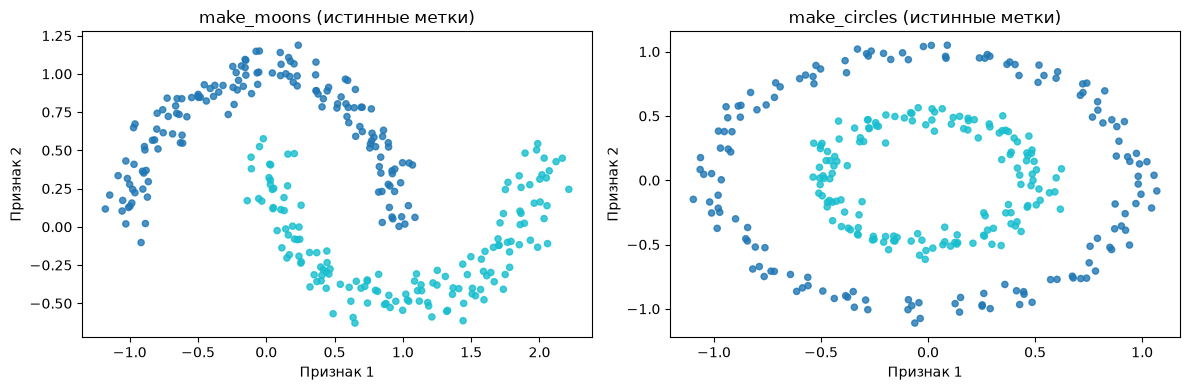

In [11]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

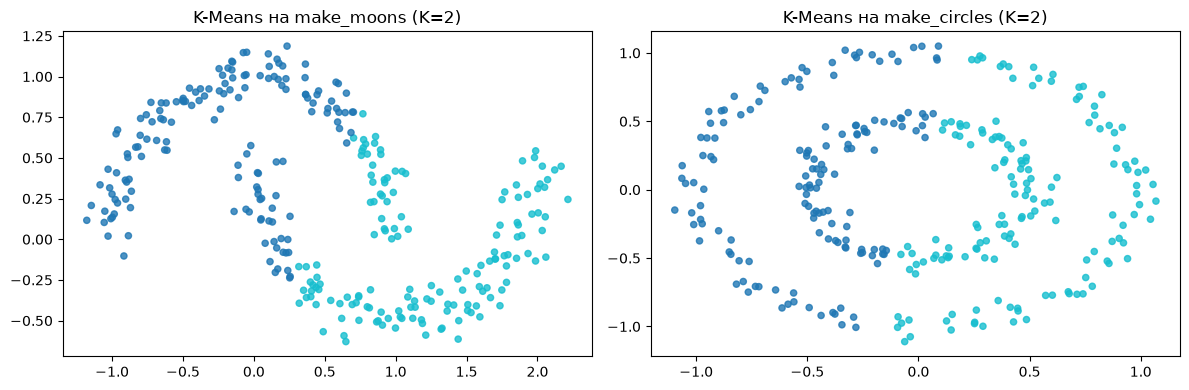

In [12]:
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

K-Means минимизирует внутрикластерную дисперсию и строит выпуклые кластеры. «Луны» и «кольца» — нелинейные структуры, поэтому K-Means режет их линейными границами.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

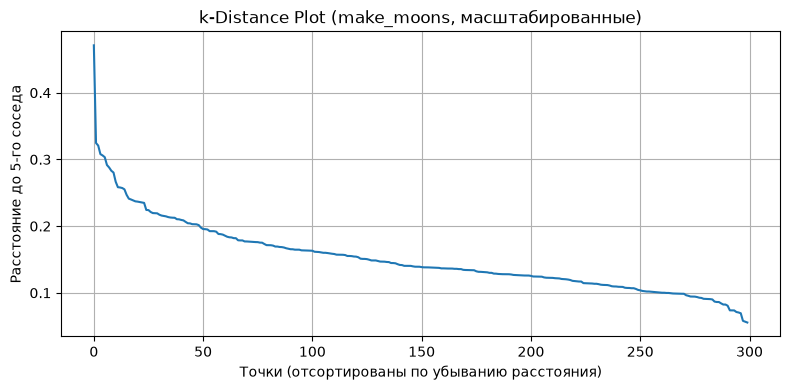

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [13]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)
distances, _ = nn.kneighbors(X_moons_scaled)
k_distances_moons = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

«Локоть» около eps ≈ 0.25: до него — плотные точки кластеров, после — разреженные межкластерные расстояния.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

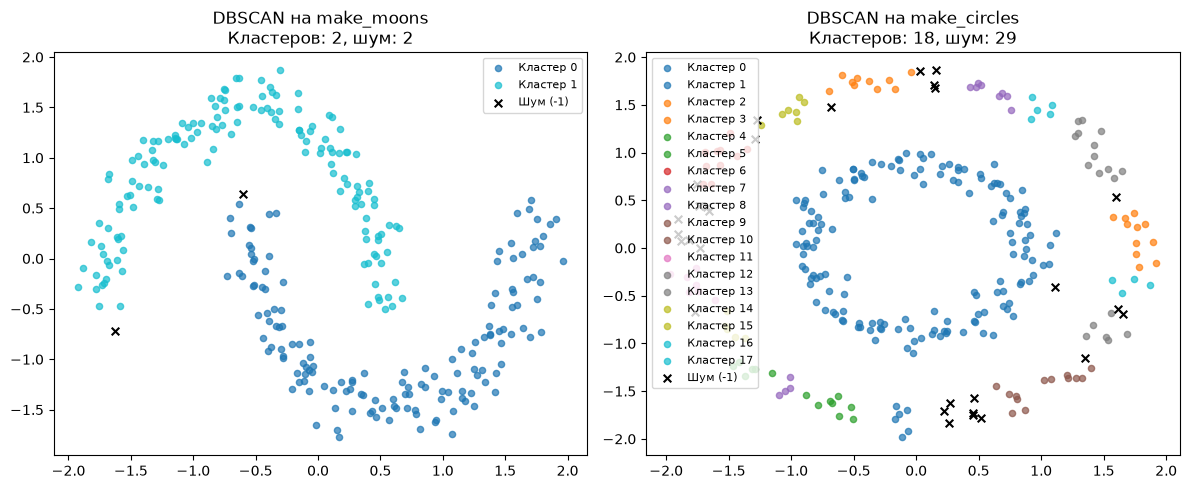

In [14]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

db_moons = DBSCAN(eps=0.25, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.20, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [15]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons_scaled = kmeans_moons.fit_predict(X_moons_scaled)

score_kmeans = silhouette_score(X_moons_scaled, labels_km_moons_scaled)

mask = labels_db_moons != -1
score_dbscan = silhouette_score(X_moons_scaled[mask], labels_db_moons[mask])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.387


DBSCAN обычно даёт лучший силуэт на moons, что совпадает с визуализацией. Но силуэт предполагает компактные кластеры — для нелинейных форм и шума это не абсолютная мера.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

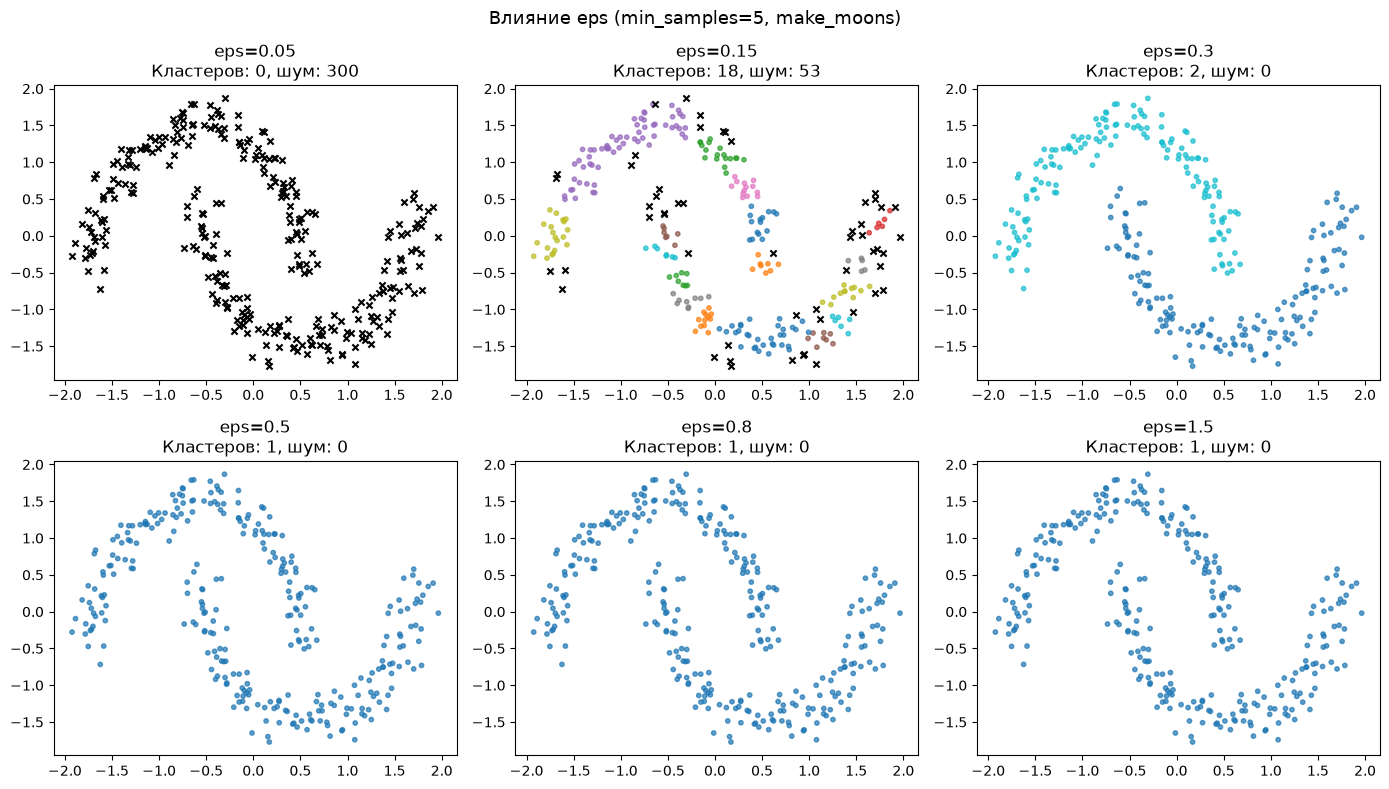

In [16]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    labels_i = DBSCAN(eps=eps_val, min_samples=5).fit_predict(X_moons_scaled)

    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()
    noise_mask = labels_i == -1
    axes[i].scatter(X_moons_scaled[~noise_mask, 0], X_moons_scaled[~noise_mask, 1],
                    c=labels_i[~noise_mask], cmap='tab10', s=10, alpha=0.7)
    axes[i].scatter(X_moons_scaled[noise_mask, 0], X_moons_scaled[noise_mask, 1],
                    c='black', marker='x', s=20)
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

Оптимально eps ≈ 0.15–0.3 (2 кластера). Малое eps → много шума; большое → сливаются кластеры в один.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [17]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

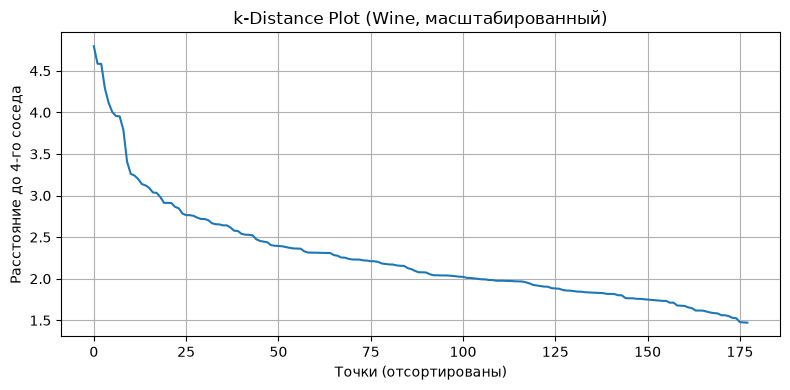

In [18]:
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

k_wine = 4
nn_wine = NearestNeighbors(n_neighbors=k_wine)
nn_wine.fit(X_wine_scaled)
dist_wine, _ = nn_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(dist_wine[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
eps_wine = 2.1

labels_wine = DBSCAN(eps=eps_wine, min_samples=4).fit_predict(X_wine_scaled)

n_clusters = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise = (labels_wine == -1).sum()
noise_frac = n_noise / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"Кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise} ({noise_frac:.1%})")

if n_clusters > 1:
    mask = labels_wine != -1
    sil = silhouette_score(X_wine_scaled[mask], labels_wine[mask])
    print(f"Силуэт (без шума): {sil:.3f}")

=== Результаты DBSCAN на Wine ===
Кластеров: 3
Шумовых точек: 57 (32.0%)
Силуэт (без шума): 0.211


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [20]:
noise_mask_wine = labels_wine == -1
X_wine_noise = X_wine[noise_mask_wine]

df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)
mean_all = df_wine.mean()
mean_noise = df_noise.mean()
diff = (mean_noise - mean_all).abs().sort_values(ascending=False)

print("=== Средние значения признаков ===")
print(pd.DataFrame({'все': mean_all, 'шум': mean_noise, '|diff|': diff}).round(2))
print(f"\nСильнее всего отличаются: {list(diff.head(3).index)}")

=== Средние значения признаков ===
                                 все     шум  |diff|
alcalinity_of_ash              19.49   20.09    0.59
alcohol                        13.00   12.74    0.26
ash                             2.37    2.35    0.01
color_intensity                 5.06    4.45    0.61
flavanoids                      2.03    2.02    0.01
hue                             0.96    0.97    0.02
magnesium                      99.74  101.11    1.36
malic_acid                      2.34    2.55    0.21
nonflavanoid_phenols            0.36    0.37    0.01
od280/od315_of_diluted_wines    2.61    2.54    0.07
proanthocyanins                 1.59    1.71    0.12
proline                       746.89  645.35  101.54
total_phenols                   2.30    2.34    0.05

Сильнее всего отличаются: ['proline', 'magnesium', 'color_intensity']


Шумовые точки — пограничные/атипичные образцы, не обязательно ошибки. Это могут быть реальные аномалии или гибридные вина между сортами.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Силуэт K-Means (K=3): 0.285
Силуэт DBSCAN:             0.211


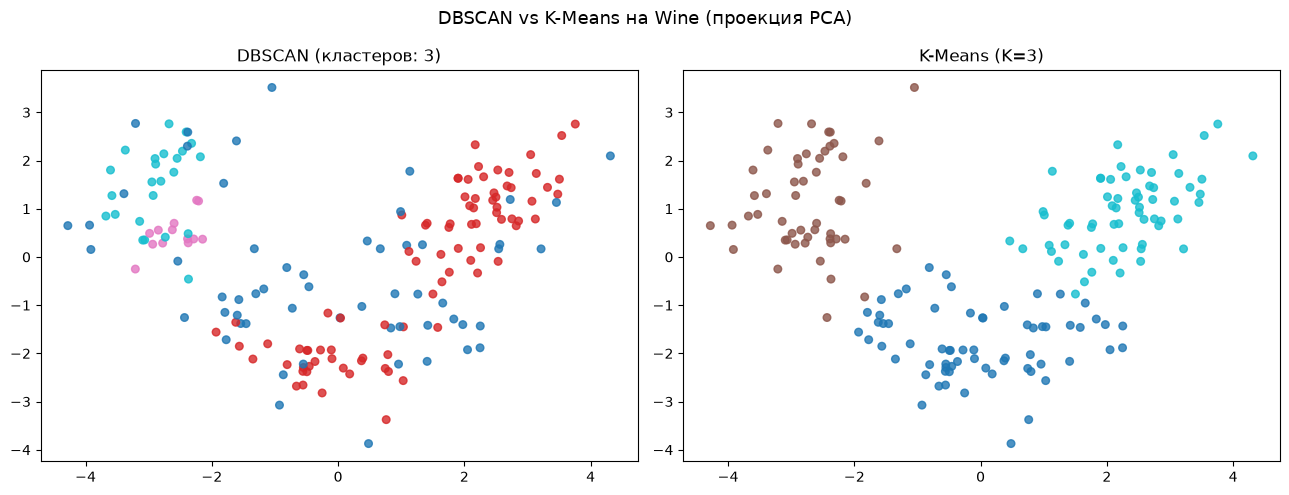

In [21]:
from sklearn.decomposition import PCA

n_cl_db = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_km = max(n_cl_db, 3)

kmeans_wine = KMeans(n_clusters=n_km, random_state=RANDOM_STATE)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)

sil_km = silhouette_score(X_wine_scaled, labels_km_wine)
mask_w = labels_wine != -1
sil_db = silhouette_score(X_wine_scaled[mask_w], labels_wine[mask_w]) if n_cl_db > 1 else np.nan

print(f"Силуэт K-Means (K={n_km}): {sil_km:.3f}")
print(f"Силуэт DBSCAN:             {sil_db:.3f}")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_wine, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title(f'DBSCAN (кластеров: {n_cl_db})')

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_km_wine, cmap='tab10', s=30, alpha=0.8)
axes[1].set_title(f'K-Means (K={n_km})')

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> На нелинейных кластерах произвольной формы (moons, circles), когда число кластеров неизвестно и нужно выделять шум.

**2. Когда K-Means предпочтительнее?**

> Компактные сферические кластеры, известное K, большие данные, нужна скорость и простота.

**3. Почему масштабирование обязательно для DBSCAN?**

> DBSCAN основан на ε-расстояниях; без масштабирования признаки с большим разбросом доминируют.

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Атипичные образцы на границе кластеров — возможные гибриды сортов или выбросы, требующие отдельного анализа.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет полностью: у DBSCAN исключаются шумовые точки, число кластеров может отличаться, метки не сопоставимы.